# Análisis y Clustering de Ventas Globales de Videojuegos

**Autor**: Juan Diego Argüello Nájera  
**Herramientas**: Python · pandas · NumPy · scikit-learn · Seaborn · Matplotlib  
**Dataset**: Video Game Sales — Kaggle  
**Link dataset**: https://www.kaggle.com/datasets/gregorut/videogamesales

---

## Objetivo

Explorar patrones de ventas globales de videojuegos por plataforma, género y región,
y aplicar clustering para identificar grupos de títulos con perfiles de distribución
de ventas similares entre mercados.

## Estructura del notebook

1. Carga y exploración inicial (shape, info, nulos, duplicados)  
2. Análisis de géneros más populares  
3. Análisis de plataformas más vendidas  
4. Distribución de ventas por región (NA, EU, JP, Other)  
5. Matriz de correlación entre variables de ventas  
6. Filtrado del periodo 2014–2020  
7. Normalización con MinMaxScaler  
8. PCA estándar + Kernel PCA (kernel RBF)  
9. Clustering con K-Means  
10. Visualización e interpretación de clusters  

---
> **Para ejecutar**: descarga `vgsales.csv` desde Kaggle y colócalo en `/data/`.
> O usa el archivo incluido en este repositorio (dataset público).

In [ ]:
import pandas as pd
import seaborn  as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn.cluster import KMeans

## Carga y exploración de los datos

Cargamos los datos del archivo CSV y realizamos una exploración básica utilizando varios métodos para obtener información sobre el DataFrame.

In [ ]:
import os
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data")

data = pd.read_csv(os.path.join(DATA_DIR, "vgsales.csv"))
data

In [ ]:
data=pd.read_csv("/content/drive/MyDrive/Clustering aplicado a Segmentacion de mercado/Ventas de video juegos/vgsales.csv")
data

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [ ]:
data.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
data.tail()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


In [ ]:
data.shape

(16598, 11)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:
data.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


## Manejo de valores nulos y duplicados

- Se eliminan los valores nulos con `data.dropna()`.
- Se verifica si existen duplicados en los datos con `data.duplicated()`.


In [ ]:
data=data.dropna()
data

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [ ]:
data.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,0
Genre,0
Publisher,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [ ]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
16593,False
16594,False
16595,False
16596,False


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  float64
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


In [ ]:
data.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

In [ ]:
data.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000
mean,8290.190228,2006.405561,0.265647,0.147731,0.078833,0.048426,0.540910
std,4792.654450,5.832412,0.822432,0.509303,0.311879,0.190083,1.567345
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4132.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8292.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12439.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [ ]:
data['Genre'].value_counts()

,count
Genre,
Action,3251
Sports,2304
Misc,1686
Role-Playing,1470
Shooter,1282
Adventure,1274
Racing,1225
Platform,875
Simulation,848


## Análisis de la variable "Genre" (Género)

En esta sección visualizamos el género de los videojuegos más vendidos:

Usamos un gráfico de barras con **seaborn** para contar cuántos juegos pertenecen a cada género.

<Axes: title={'center': 'Género más vendido.'}, xlabel='Genre', ylabel='count'>

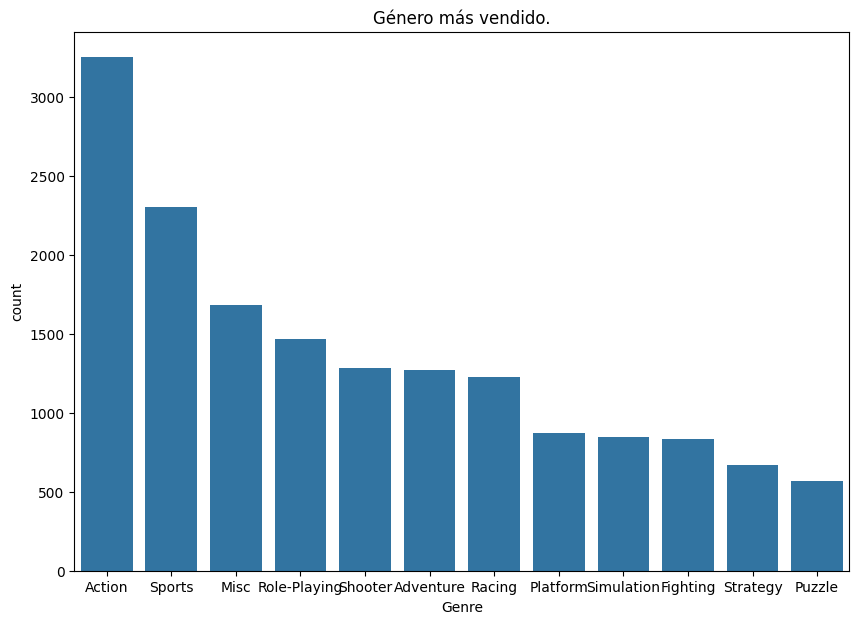

In [ ]:
plt.figure(figsize=(10,7))
plt.title('Género más vendido.')
sns.countplot(data=data, x = 'Genre', order = data['Genre'].value_counts().index)

## Análisis de las plataformas más vendidas

Ahora, visualizamos las plataformas más vendidas utilizando un gráfico de barras similar al anterior, pero esta vez con la variable `Platform`.


<Axes: title={'center': 'Qué plataforma hace los juegos más vendidos'}, xlabel='Platform', ylabel='count'>

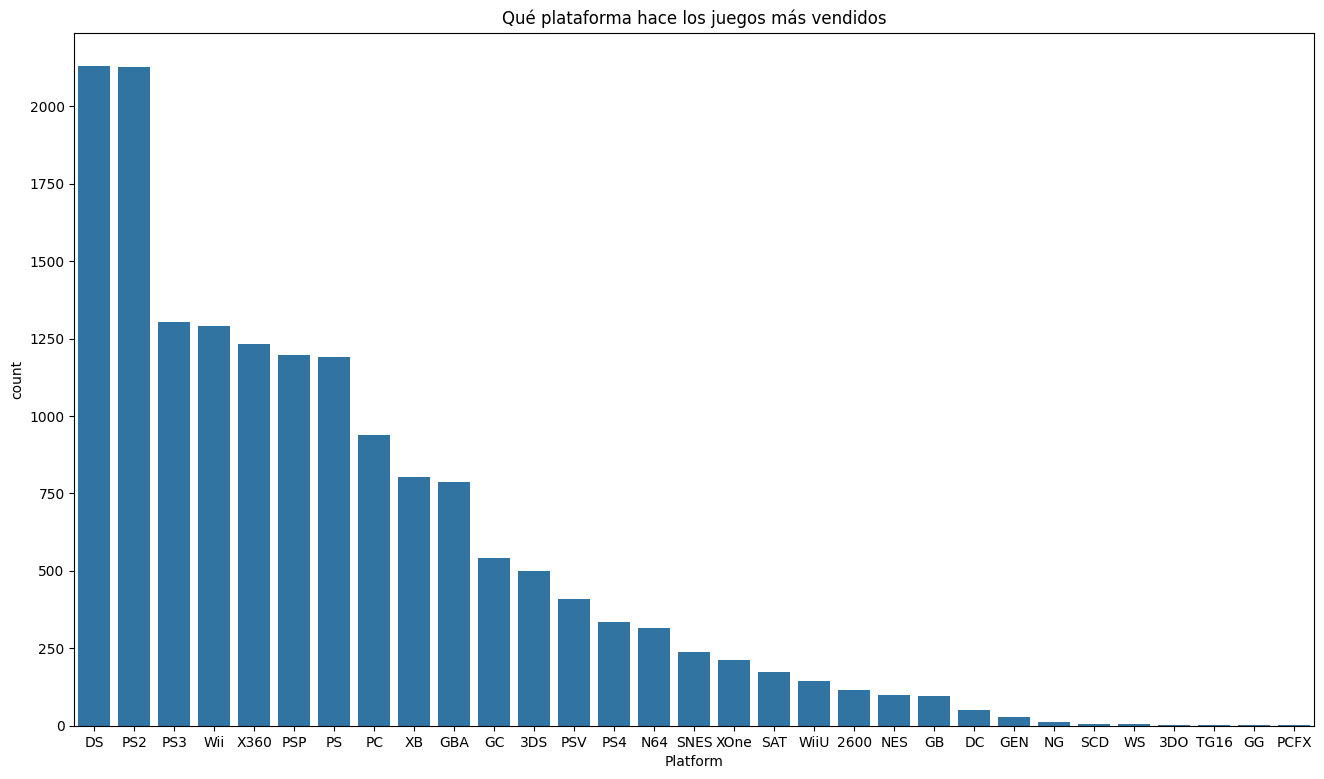

In [ ]:
plt.figure(figsize=(16,9))
plt.title('Qué plataforma hace los juegos más vendidos')
sns.countplot(data=data, x = 'Platform', order = data['Platform'].value_counts().index)

Nunca usen diagramas de este tipo.

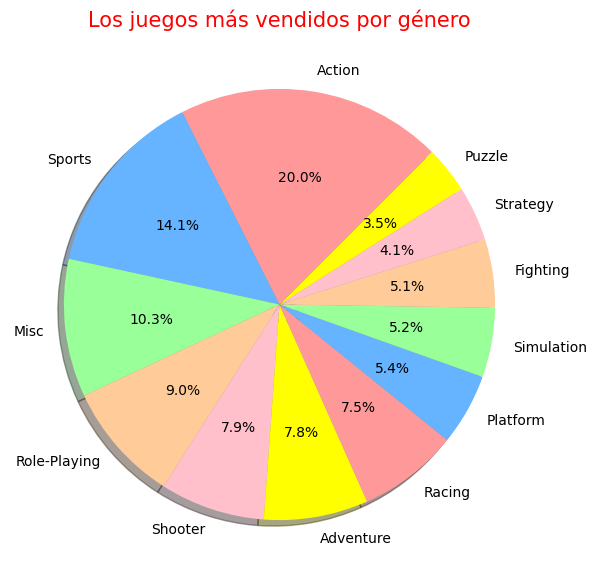

In [ ]:
labels = data["Genre"].value_counts().index
sizes = data["Genre"].value_counts()
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99',"pink","yellow"]
plt.figure(figsize = (7,7))
plt.pie(sizes, labels=labels, rotatelabels=False, autopct='%1.1f%%',colors=colors,shadow=True, startangle=45)
plt.title('Los juegos más vendidos por género',color = 'red',fontsize = 15)

plt.show()

<Axes: xlabel='Year', ylabel='count'>

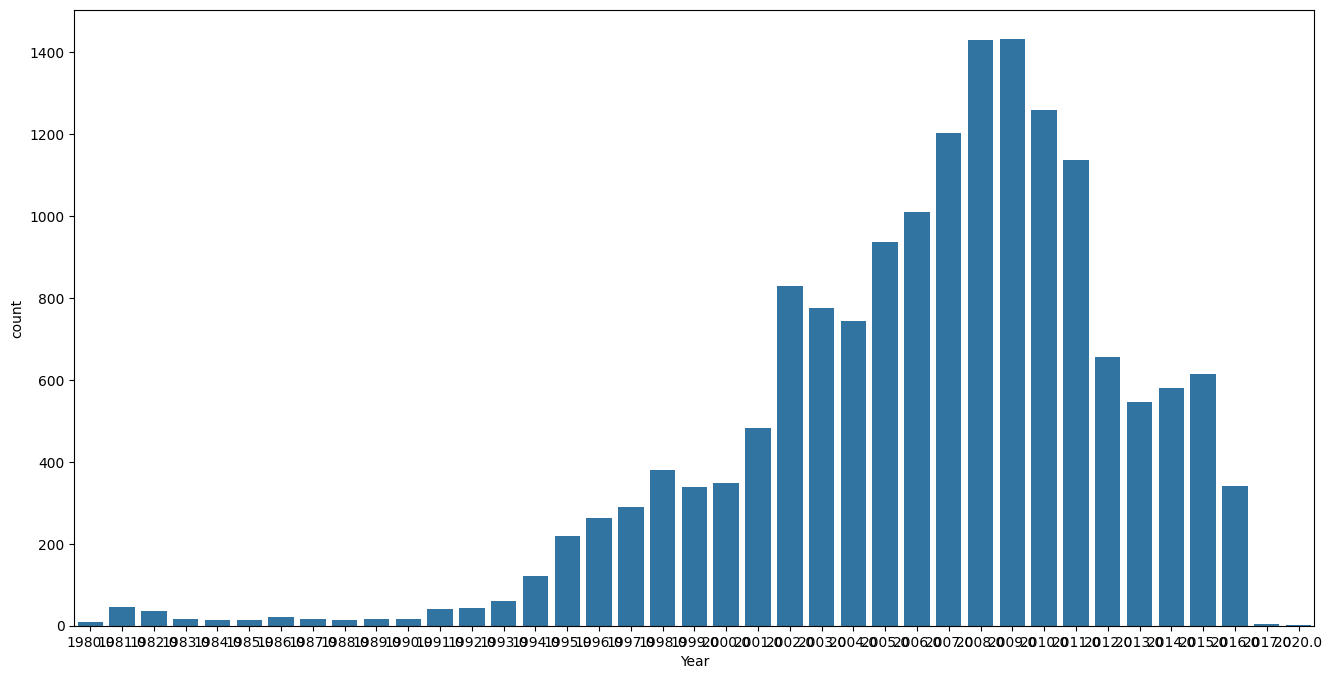

In [ ]:
plt.figure(figsize=(16,8))
sns.countplot(data=data,x='Year',)

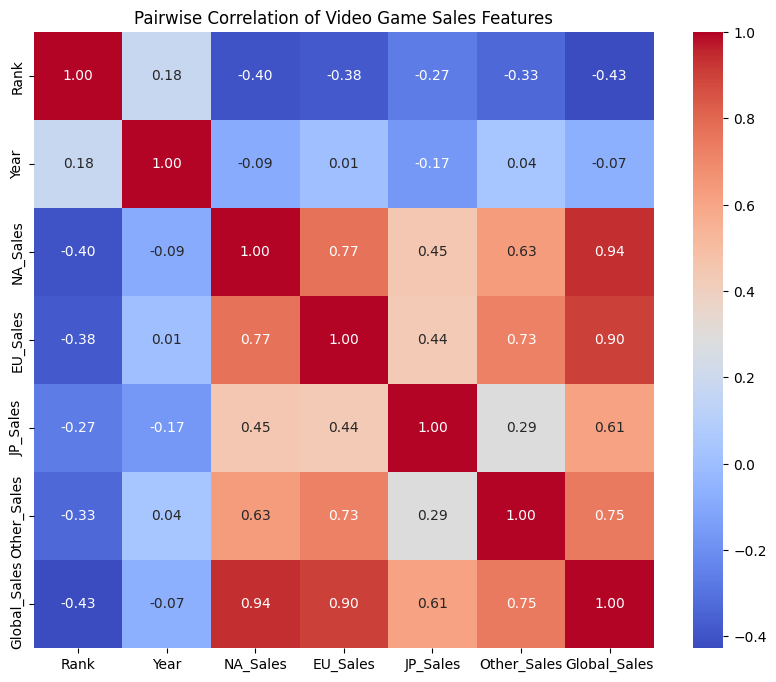

In [ ]:
numeric_columns = data.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numeric_columns.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pairwise Correlation of Video Game Sales Features')
plt.show()

## Análisis de ventas por región

Creamos un gráfico de pastel para mostrar la distribución de las ventas en diferentes regiones (`NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales`).

La función `melt` se usa para transformar los datos de un formato amplio a largo, para poder agrupar y graficar las ventas por región.


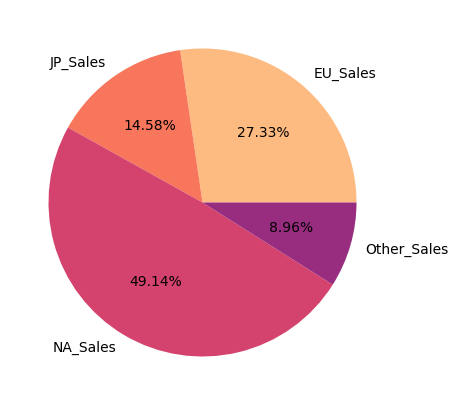

In [ ]:
area_sales = data[['NA_Sales','EU_Sales', 'JP_Sales', 'Other_Sales']]
area_sales = area_sales.melt(var_name='Area',value_name='Total_Sales')
area_sales = area_sales.groupby('Area')['Total_Sales'].sum().reset_index()

plt.figure(figsize=(10,5))
plt.pie(area_sales['Total_Sales'],labels=area_sales['Area'],colors=sns.color_palette('magma_r'),autopct='%.2f%%')
plt.show()

## Filtrado de los datos (2016-2020)

En esta sección, conservamos sólo los datos correspondientes a los años 2016-2020, eliminando las columnas no relevantes (`Rank`, `Name`, `Year`, `Global_Sales`).


In [ ]:
data_filtrada = data[(data['Year'] >= 2014) & (data['Year'] <= 2020)]
data_filtrada

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
33,34,Call of Duty: Black Ops 3,PS4,2015.0,Shooter,Activision,5.77,5.81,0.35,2.31,14.24
44,45,Grand Theft Auto V,PS4,2014.0,Action,Take-Two Interactive,3.80,5.81,0.36,2.02,11.98
49,50,Pokemon Omega Ruby/Pokemon Alpha Sapphire,3DS,2014.0,Role-Playing,Nintendo,4.23,3.37,3.08,0.65,11.33
77,78,FIFA 16,PS4,2015.0,Sports,Electronic Arts,1.11,6.06,0.06,1.26,8.49
92,93,Star Wars Battlefront (2015),PS4,2015.0,Shooter,Electronic Arts,2.93,3.29,0.22,1.23,7.67
...,...,...,...,...,...,...,...,...,...,...,...
16567,16570,Fujiko F. Fujio Characters: Great Assembly! Sl...,3DS,2014.0,Action,Namco Bandai Games,0.00,0.00,0.01,0.00,0.01
16569,16572,Resident Evil 4 HD,XOne,2016.0,Shooter,Capcom,0.01,0.00,0.00,0.00,0.01
16570,16573,Farming 2017 - The Simulation,PS4,2016.0,Simulation,UIG Entertainment,0.00,0.01,0.00,0.00,0.01
16576,16579,Rugby Challenge 3,XOne,2016.0,Sports,Alternative Software,0.00,0.01,0.00,0.00,0.01


In [ ]:
data_filtrada.drop(columns=['Rank', 'Name', 'Year', 'Global_Sales'], inplace=True)
data_filtrada

<ipython-input-120-89a7a3ca0b75>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtrada.drop(columns=['Rank', 'Name', 'Year', 'Global_Sales'], inplace=True)


,Platform,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales
33,PS4,Shooter,Activision,5.77,5.81,0.35,2.31
44,PS4,Action,Take-Two Interactive,3.80,5.81,0.36,2.02
49,3DS,Role-Playing,Nintendo,4.23,3.37,3.08,0.65
77,PS4,Sports,Electronic Arts,1.11,6.06,0.06,1.26
92,PS4,Shooter,Electronic Arts,2.93,3.29,0.22,1.23
...,...,...,...,...,...,...,...
16567,3DS,Action,Namco Bandai Games,0.00,0.00,0.01,0.00
16569,XOne,Shooter,Capcom,0.01,0.00,0.00,0.00
16570,PS4,Simulation,UIG Entertainment,0.00,0.01,0.00,0.00
16576,XOne,Sports,Alternative Software,0.00,0.01,0.00,0.00


## Exploración de la relación entre ventas

Creamos un gráfico de dispersión entre las ventas en las diferentes regiones. Este gráfico nos ayuda a identificar relaciones y patrones entre las variables.


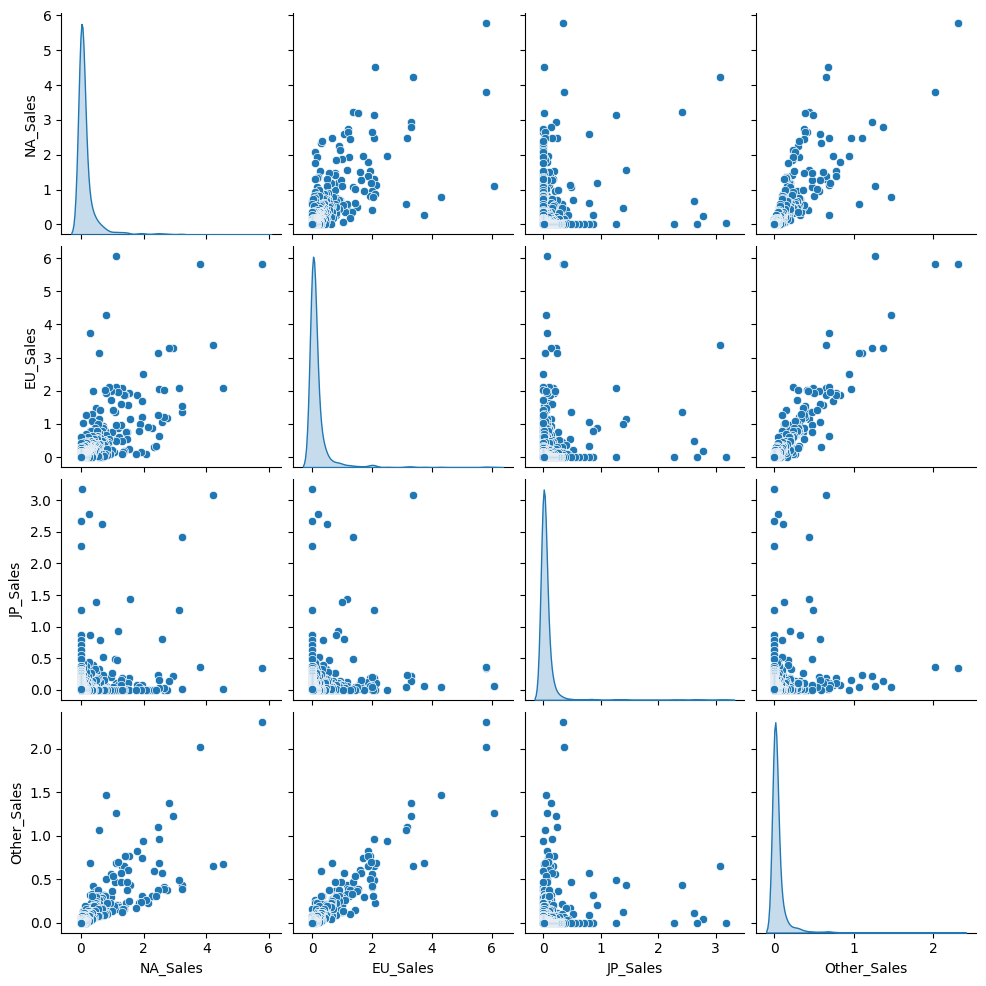

In [ ]:
# Seleccionamos las columnas numéricas para el gráfico de dispersión
ventas = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Creamos el pairplot (diagrama de dispersión entre todas las combinaciones de las columnas)
sns.pairplot(data_filtrada, vars=ventas, diag_kind='kde')

# Muestra el gráfico
plt.show()

## Normalización de los datos

Usamos el **MinMaxScaler** de `sklearn` para normalizar las columnas de ventas, lo que asegura que todas las variables tengan el mismo rango, facilitando su uso en técnicas como PCA o clustering.


In [ ]:
# Seleccionamos las columnas que vamos a normalizar
columnas_a_normalizar = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Creamos una copia del DataFrame para no modificar el original
data_normalizada = data_filtrada.copy()

# Inicializamos el escalador Min-Max
scaler = MinMaxScaler()

# Aplicamos la normalización a las columnas seleccionadas
data_normalizada[columnas_a_normalizar] = scaler.fit_transform(data_normalizada[columnas_a_normalizar])

data_normalizada.head()


,Platform,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales
33,PS4,Shooter,Activision,1.000000,0.958746,0.110063,1.000000
44,PS4,Action,Take-Two Interactive,0.658579,0.958746,0.113208,0.874459
49,3DS,Role-Playing,Nintendo,0.733102,0.556106,0.968553,0.281385
77,PS4,Sports,Electronic Arts,0.192374,1.000000,0.018868,0.545455
92,PS4,Shooter,Electronic Arts,0.507799,0.542904,0.069182,0.532468


## Análisis mediante PCA (Análisis de Componentes Principales)

Aplicamos PCA para reducir la dimensionalidad de los datos de ventas. Seleccionamos 2 componentes principales y visualizamos el resultado en un diagrama de dispersión.


In [ ]:
# Seleccionamos las columnas a las que se les aplicará PCA
columnas_a_pca = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Creamos una copia del DataFrame para no modificar el original
data_pca = data_normalizada.copy()

# Inicializamos el PCA con 2 componentes
pca = PCA(n_components=2)

# Aplicamos PCA y obtenemos las nuevas coordenadas
componentes_principales = pca.fit_transform(data_pca[columnas_a_pca])

# Creamos nuevas columnas con las coordenadas de las dos primeras componentes principales
data_pca['PCA_1'] = componentes_principales[:, 0]
data_pca['PCA_2'] = componentes_principales[:, 1]


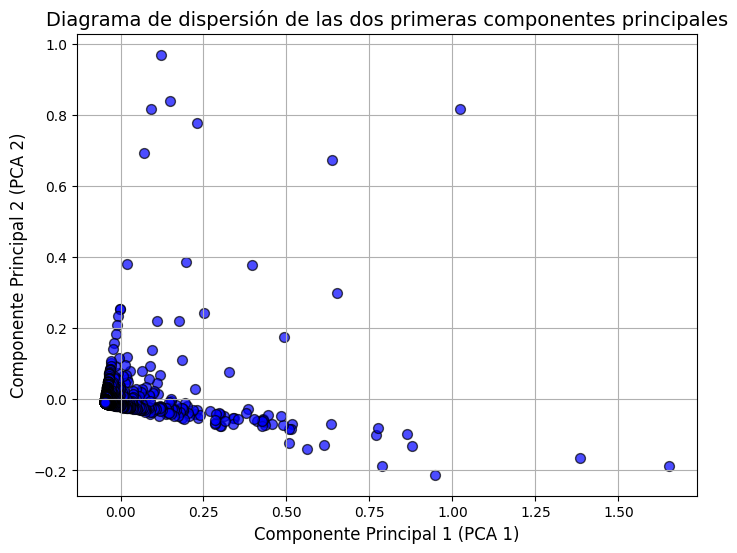

In [ ]:
# Crear el diagrama de dispersión
plt.figure(figsize=(8, 6))
plt.scatter(data_pca['PCA_1'], data_pca['PCA_2'], alpha=0.7, c='blue', edgecolors='k', s=50)

# Etiquetas y título
plt.title('Diagrama de dispersión de las dos primeras componentes principales', fontsize=14)
plt.xlabel('Componente Principal 1 (PCA 1)', fontsize=12)
plt.ylabel('Componente Principal 2 (PCA 2)', fontsize=12)

# Mostrar el gráfico
plt.grid(True)
plt.show()

In [ ]:
# Seleccionamos las columnas a las que se les aplicará Kernel PCA
columnas_a_pca = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Creamos una copia del DataFrame para no modificar el original
data_kernel_pca = data_normalizada.copy()

# Inicializamos KernelPCA con un kernel polinomial (degree=3, coef0=1)
kernel_pca = KernelPCA(n_components=2, kernel='poly', degree=3, coef0=1)

# Aplicamos KernelPCA y obtenemos las nuevas coordenadas
componentes_principales_kernel = kernel_pca.fit_transform(data_kernel_pca[columnas_a_pca])

# Creamos nuevas columnas con las coordenadas de las dos primeras componentes principales
data_kernel_pca['Kernel_PCA_1'] = componentes_principales_kernel[:, 0]
data_kernel_pca['Kernel_PCA_2'] = componentes_principales_kernel[:, 1]

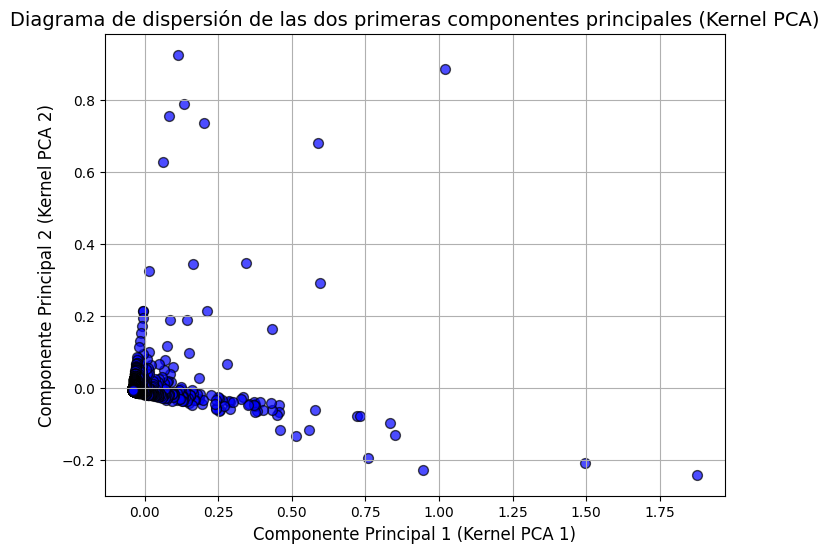

In [ ]:
# Crear el diagrama de dispersión con KernelPCA
plt.figure(figsize=(8, 6))
plt.scatter(data_kernel_pca['Kernel_PCA_1'], data_kernel_pca['Kernel_PCA_2'], alpha=0.7, c='blue', edgecolors='k', s=50)

# Etiquetas y título
plt.title('Diagrama de dispersión de las dos primeras componentes principales (Kernel PCA)', fontsize=14)
plt.xlabel('Componente Principal 1 (Kernel PCA 1)', fontsize=12)
plt.ylabel('Componente Principal 2 (Kernel PCA 2)', fontsize=12)

# Mostrar el gráfico
plt.grid(True)
plt.show()

In [ ]:
# Seleccionamos las columnas a las que se les aplicará Kernel PCA
columnas_a_pca = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Creamos una copia del DataFrame para no modificar el original
data_kernel_pca = data_normalizada.copy()

# Inicializamos KernelPCA con un kernel RBF
kernel_pca_rbf = KernelPCA(n_components=2, kernel='rbf', gamma=10)

# Aplicamos KernelPCA con kernel RBF y obtenemos las nuevas coordenadas
componentes_principales_rbf = kernel_pca_rbf.fit_transform(data_kernel_pca[columnas_a_pca])

# Creamos nuevas columnas con las coordenadas de las dos primeras componentes principales
data_kernel_pca['Kernel_PCA_RBF_1'] = componentes_principales_rbf[:, 0]
data_kernel_pca['Kernel_PCA_RBF_2'] = componentes_principales_rbf[:, 1]

# Ahora 'data_kernel_pca' contiene las dos primeras componentes principales con kernel RBF


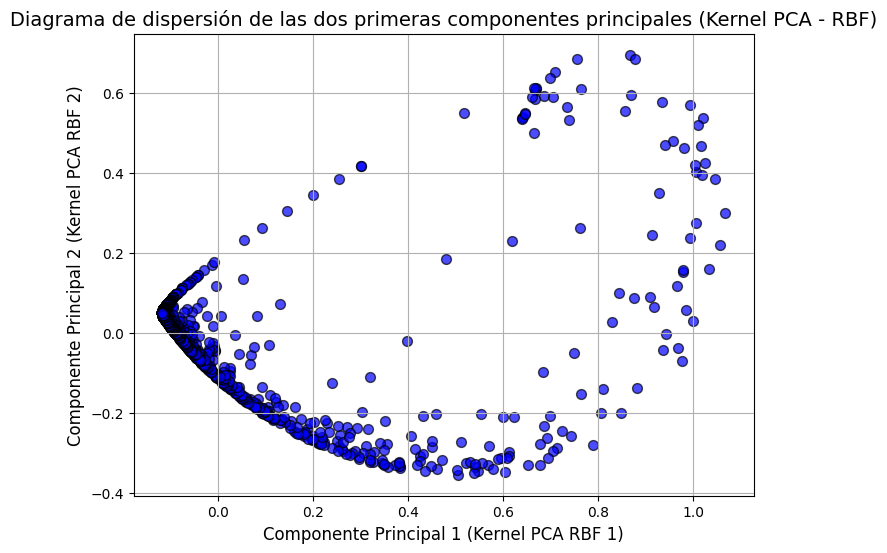

In [ ]:
# Crear el diagrama de dispersión con KernelPCA (RBF)
plt.figure(figsize=(8, 6))
plt.scatter(data_kernel_pca['Kernel_PCA_RBF_1'], data_kernel_pca['Kernel_PCA_RBF_2'], alpha=0.7, c='blue', edgecolors='k', s=50)

# Etiquetas y título
plt.title('Diagrama de dispersión de las dos primeras componentes principales (Kernel PCA - RBF)', fontsize=14)
plt.xlabel('Componente Principal 1 (Kernel PCA RBF 1)', fontsize=12)
plt.ylabel('Componente Principal 2 (Kernel PCA RBF 2)', fontsize=12)

# Mostrar el gráfico
plt.grid(True)
plt.show()

In [ ]:
# Seleccionamos las columnas a las que se les aplicará Kernel PCA
columnas_a_pca = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Creamos una copia del DataFrame para no modificar el original
data_kernel_pca = data_normalizada.copy()

# Inicializamos KernelPCA con un kernel sigmoide
kernel_pca_sigmoid = KernelPCA(n_components=2, kernel='sigmoid', gamma=10, coef0=1)

# Aplicamos KernelPCA con kernel sigmoide y obtenemos las nuevas coordenadas
componentes_principales_sigmoid = kernel_pca_sigmoid.fit_transform(data_kernel_pca[columnas_a_pca])

# Creamos nuevas columnas con las coordenadas de las dos primeras componentes principales
data_kernel_pca['Kernel_PCA_Sigmoid_1'] = componentes_principales_sigmoid[:, 0]
data_kernel_pca['Kernel_PCA_Sigmoid_2'] = componentes_principales_sigmoid[:, 1]

# Ahora 'data_kernel_pca' contiene las dos primeras componentes principales con kernel sigmoide

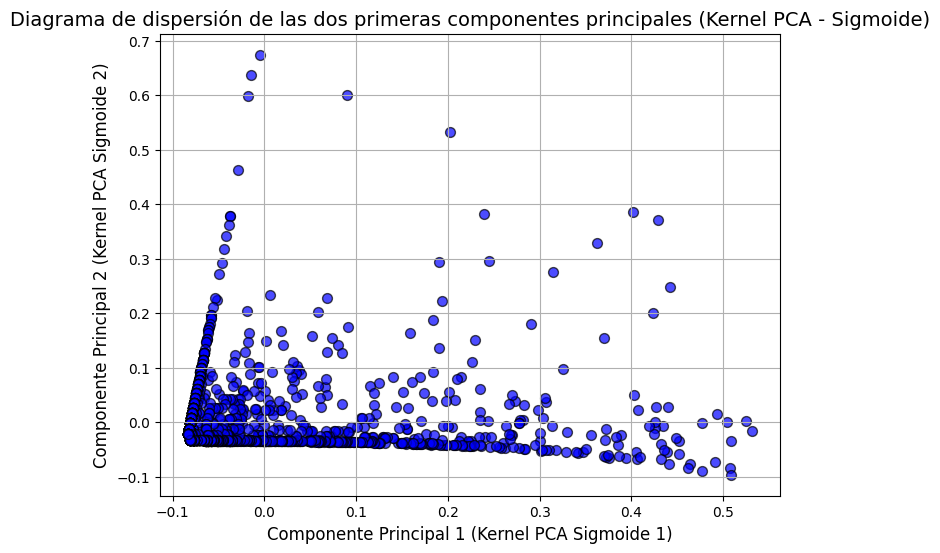

In [ ]:
# Crear el diagrama de dispersión con KernelPCA (sigmoide)
plt.figure(figsize=(8, 6))
plt.scatter(data_kernel_pca['Kernel_PCA_Sigmoid_1'], data_kernel_pca['Kernel_PCA_Sigmoid_2'], alpha=0.7, c='blue', edgecolors='k', s=50)

# Etiquetas y título
plt.title('Diagrama de dispersión de las dos primeras componentes principales (Kernel PCA - Sigmoide)', fontsize=14)
plt.xlabel('Componente Principal 1 (Kernel PCA Sigmoide 1)', fontsize=12)
plt.ylabel('Componente Principal 2 (Kernel PCA Sigmoide 2)', fontsize=12)

# Mostrar el gráfico
plt.grid(True)
plt.show()


In [ ]:
# Seleccionamos las columnas a las que se les aplicará Kernel PCA
columnas_a_pca = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Creamos una copia del DataFrame para no modificar el original
data_kernel_pca = data_normalizada.copy()

# Inicializamos KernelPCA con un kernel sigmoide
kernel_pca_cosine = KernelPCA(n_components=2, kernel='cosine')

# Aplicamos KernelPCA con kernel sigmoide y obtenemos las nuevas coordenadas
componentes_principales_cosine = kernel_pca_cosine.fit_transform(data_kernel_pca[columnas_a_pca])

# Creamos nuevas columnas con las coordenadas de las dos primeras componentes principales
data_kernel_pca['Kernel_PCA_Cosine_1'] = componentes_principales_cosine[:, 0]
data_kernel_pca['Kernel_PCA_Cosine_2'] = componentes_principales_cosine[:, 1]


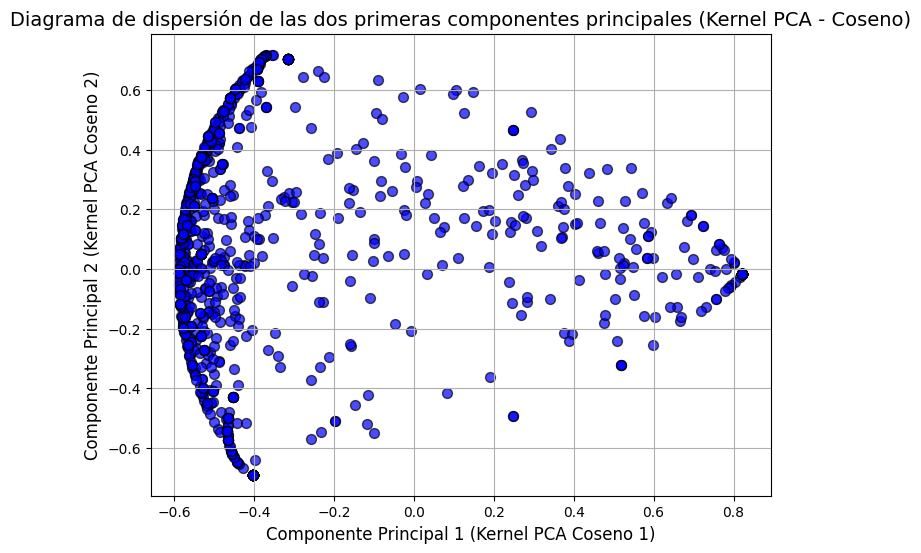

In [ ]:
# Crear el diagrama de dispersión con KernelPCA (Coseno)
plt.figure(figsize=(8, 6))
plt.scatter(data_kernel_pca['Kernel_PCA_Cosine_1'], data_kernel_pca['Kernel_PCA_Cosine_2'], alpha=0.7, c='blue', edgecolors='k', s=50)

# Etiquetas y título
plt.title('Diagrama de dispersión de las dos primeras componentes principales (Kernel PCA - Coseno)', fontsize=14)
plt.xlabel('Componente Principal 1 (Kernel PCA Coseno 1)', fontsize=12)
plt.ylabel('Componente Principal 2 (Kernel PCA Coseno 2)', fontsize=12)

# Mostrar el gráfico
plt.grid(True)
plt.show()


In [ ]:
data_kernel_pca.head()

,Platform,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Kernel_PCA_Cosine_1,Kernel_PCA_Cosine_2
33,PS4,Shooter,Activision,1.000000,0.958746,0.110063,1.000000,-0.517959,0.121632
44,PS4,Action,Take-Two Interactive,0.658579,0.958746,0.113208,0.874459,-0.506456,-0.037509
49,3DS,Role-Playing,Nintendo,0.733102,0.556106,0.968553,0.281385,0.155389,0.142935
77,PS4,Sports,Electronic Arts,0.192374,1.000000,0.018868,0.545455,-0.509741,-0.405923
92,PS4,Shooter,Electronic Arts,0.507799,0.542904,0.069182,0.532468,-0.512091,0.077981


## Clustering con K-Means

Aplicamos el algoritmo **K-Means** para dividir los datos en 4 clusters, utilizando las componentes principales obtenidas con Kernel PCA. Luego visualizamos los clusters en un gráfico de dispersión.

Después de aplicar el método del codo, determinamos que el número óptimo de clusters es 3, por lo que aplicamos el modelo K-Means con 3 clusters y mostramos los resultados.


In [ ]:
# Paso 1: Aplicar K-means para crear 4 clusters
kmeans = KMeans(n_clusters=4, random_state=1)
data_kernel_pca['Cluster'] = kmeans.fit_predict(data_kernel_pca[['Kernel_PCA_Cosine_1', 'Kernel_PCA_Cosine_2']])

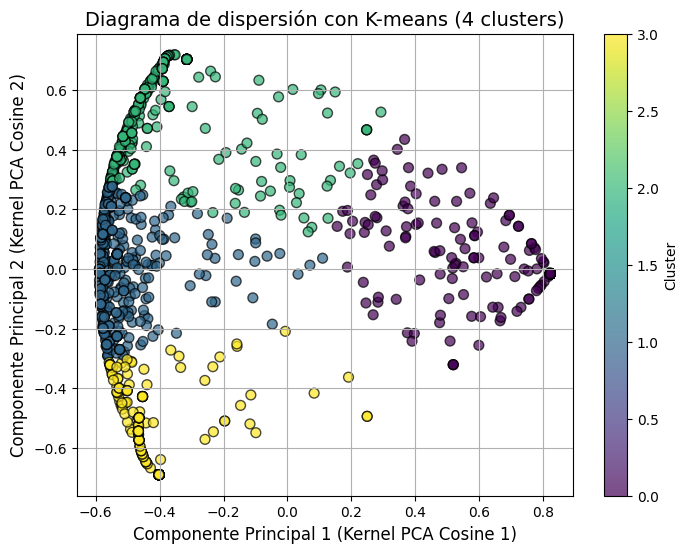

In [ ]:
# Paso 2: Graficar los resultados de los clusters
plt.figure(figsize=(8, 6))

# Usamos colores diferentes para cada cluster
plt.scatter(data_kernel_pca['Kernel_PCA_Cosine_1'],
            data_kernel_pca['Kernel_PCA_Cosine_2'],
            c=data_kernel_pca['Cluster'], cmap='viridis', alpha=0.7, edgecolors='k', s=50)

# Título y etiquetas
plt.title('Diagrama de dispersión con K-means (4 clusters)', fontsize=14)
plt.xlabel('Componente Principal 1 (Kernel PCA Cosine 1)', fontsize=12)
plt.ylabel('Componente Principal 2 (Kernel PCA Cosine 2)', fontsize=12)

# Agregar una leyenda para los clusters
plt.colorbar(label='Cluster')

# Mostrar el gráfico
plt.grid(True)
plt.show()

##Aplcamos el método del codo

In [ ]:
# Paso 1: Calcular la inercia para diferentes valores de k (de 1 a 10 clusters)
inercia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=30, random_state=1)
    kmeans.fit(data_kernel_pca[['Kernel_PCA_Cosine_1', 'Kernel_PCA_Cosine_2']])
    inercia.append(kmeans.inertia_)

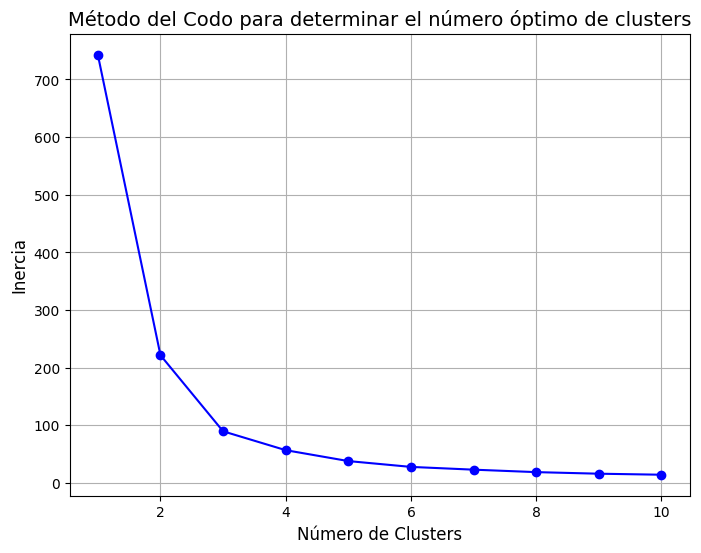

In [ ]:
# Paso 2: Graficar la inercia en función de k
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inercia, marker='o', linestyle='-', color='b')
plt.title('Método del Codo para determinar el número óptimo de clusters', fontsize=14)
plt.xlabel('Número de Clusters', fontsize=12)
plt.ylabel('Inercia', fontsize=12)
plt.grid(True)
plt.show()

## Nos quedaremos con 3 clusters

In [ ]:
# Paso 1: Aplicar K-means para crear 3 clusters
kmeans = KMeans(n_clusters=3, n_init=100, random_state=1)
data_kernel_pca['Cluster'] = kmeans.fit_predict(data_kernel_pca[['Kernel_PCA_Cosine_1', 'Kernel_PCA_Cosine_2']])

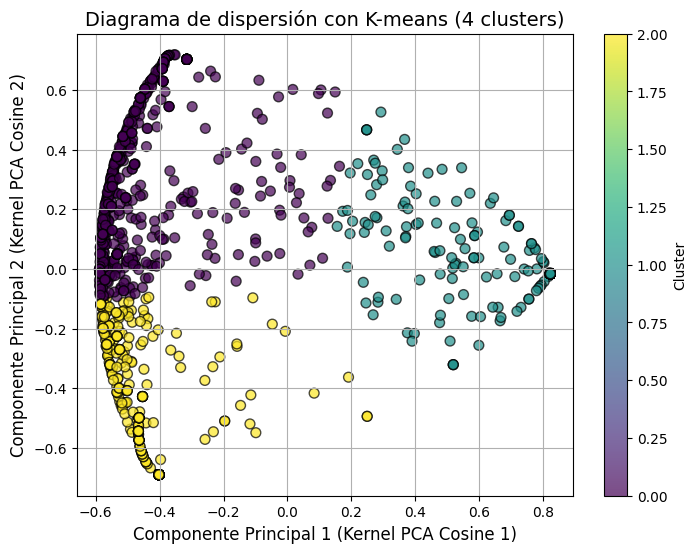

In [ ]:
# Paso 2: Graficar los resultados de los clusters
plt.figure(figsize=(8, 6))

# Usamos colores diferentes para cada cluster
plt.scatter(data_kernel_pca['Kernel_PCA_Cosine_1'],
            data_kernel_pca['Kernel_PCA_Cosine_2'],
            c=data_kernel_pca['Cluster'], cmap='viridis', alpha=0.7, edgecolors='k', s=50)

# Título y etiquetas
plt.title('Diagrama de dispersión con K-means (4 clusters)', fontsize=14)
plt.xlabel('Componente Principal 1 (Kernel PCA Cosine 1)', fontsize=12)
plt.ylabel('Componente Principal 2 (Kernel PCA Cosine 2)', fontsize=12)

# Agregar una leyenda para los clusters
plt.colorbar(label='Cluster')

# Mostrar el gráfico
plt.grid(True)
plt.show()

## Análisis de los clusters

En esta sección, agrupamos los datos por cluster y visualizamos las estadísticas descriptivas de las ventas en cada uno de los clusters. Utilizamos gráficos de cajas para comparar la distribución de las ventas entre los clusters.


In [ ]:
# Contar cuántas muestras hay en cada cluster
cluster_counts = data_kernel_pca['Cluster'].value_counts()

# Mostrar la información
print("Número de muestras por cluster:")
print(cluster_counts)


Número de muestras por cluster:
Cluster
0    598
1    576
2    366
Name: count, dtype: int64


In [ ]:
# Crea un nuevo DataFrame que contenga las columnas necesarias
data_clustered = data_filtrada.copy()  # Crear una copia de 'data' para no modificar el original

# Asegúrate de que la columna de clusters esté presente en 'data_clustered'
data_clustered['Cluster'] = data_kernel_pca['Cluster']  # Añadir la columna de clusters

data_clustered.head()

,Platform,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Cluster
33,PS4,Shooter,Activision,5.77,5.81,0.35,2.31,0
44,PS4,Action,Take-Two Interactive,3.80,5.81,0.36,2.02,0
49,3DS,Role-Playing,Nintendo,4.23,3.37,3.08,0.65,1
77,PS4,Sports,Electronic Arts,1.11,6.06,0.06,1.26,2
92,PS4,Shooter,Electronic Arts,2.93,3.29,0.22,1.23,0


In [ ]:
# Asegúrate de que la columna de clusters esté presente en 'data_clustered'
data_clustered['Cluster'] = data_kernel_pca['Cluster']  # Añadir la columna de clusters

# Agrupar por 'Cluster' y calcular las estadísticas para las columnas de ventas y las componentes principales de PCA
descripcion_por_cluster = data_clustered.groupby('Cluster')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].agg(
    ['mean', 'min', 'max', 'std']
)

# Mostrar los resultados
print(descripcion_por_cluster)



         NA_Sales                        EU_Sales                        \
             mean   min   max       std      mean   min   max       std   
Cluster                                                                   
0        0.357876  0.01  5.77  0.605967  0.258746  0.00  5.81  0.527494   
1        0.034913  0.00  4.23  0.244241  0.026962  0.00  3.37  0.175380   
2        0.064481  0.00  1.12  0.165642  0.218142  0.01  6.06  0.561311   

         JP_Sales                       Other_Sales                       
             mean   min   max       std        mean  min   max       std  
Cluster                                                                   
0        0.023010  0.00  1.27  0.080563    0.093896  0.0  2.31  0.197610  
1        0.122431  0.01  3.18  0.326544    0.008177  0.0  0.65  0.042789  
2        0.007158  0.00  0.21  0.022284    0.046284  0.0  1.47  0.141711  


# Diagramas de cajas
Empleamos diagramas de cajas para mostrar la ventas en cada región para cada cluster.

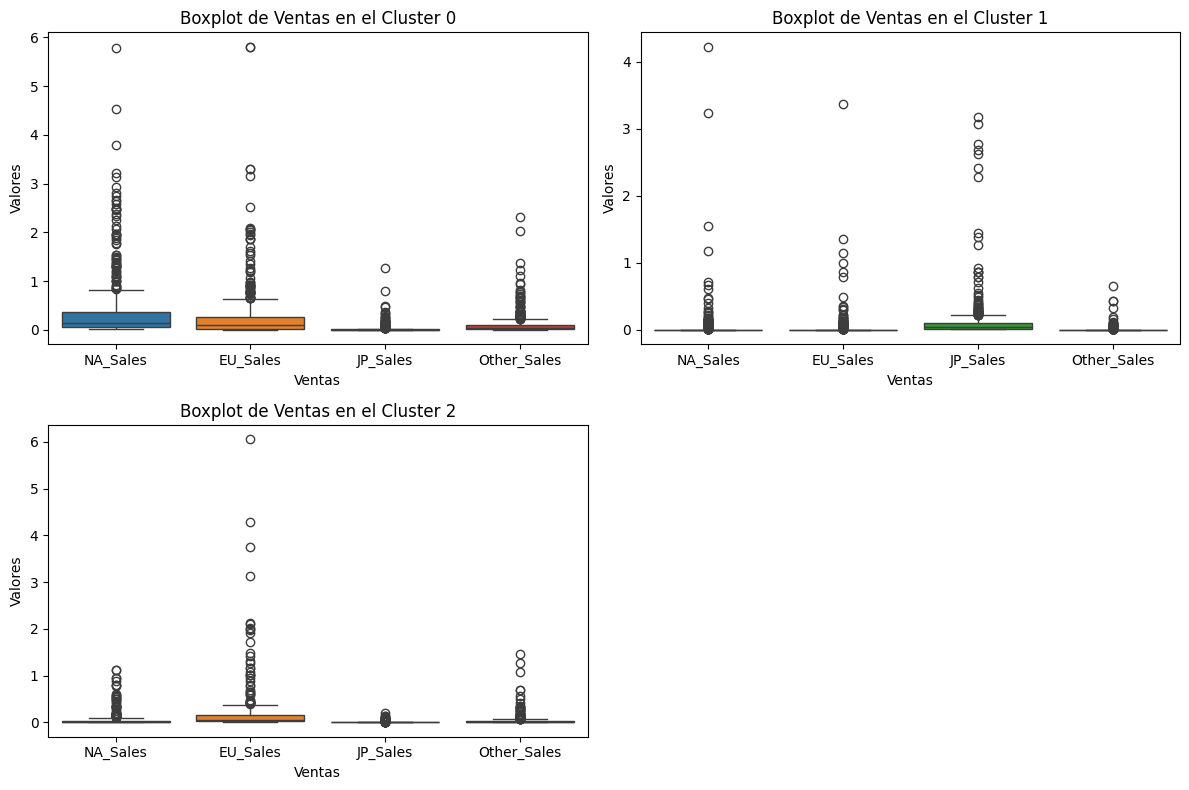

In [ ]:
# Definir las columnas de ventas
ventas = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Establecer el tamaño de la figura
plt.figure(figsize=(12, 8))

# Crear un gráfico de cajas para cada cluster
clusters = data_clustered['Cluster'].unique()

# Crear un gráfico de cajas por cluster
for i, cluster in enumerate(clusters):
    # Filtrar los datos para el cluster actual
    data_cluster = data_clustered[data_clustered['Cluster'] == cluster]

    # Crear subgráficos para cada cluster (un solo gráfico por cluster)
    plt.subplot(2, 2, i + 1)  # Usamos una cuadrícula 2x2 para los gráficos
    sns.boxplot(data=data_cluster[ventas])  # Graficamos las 4 columnas de ventas en el mismo gráfico

    # Títulos y etiquetas
    plt.title(f'Boxplot de Ventas en el Cluster {cluster}')
    plt.xlabel('Ventas')
    plt.ylabel('Valores')

# Ajustar los espacios entre los subgráficos
plt.tight_layout()
plt.show()


## Ajuste de los gráficos de cajas

Ajustamos los límites de los gráficos de cajas para mostrar el 90% central de los datos, ignorando los puntos atípicos extremos. Además, ocultamos los puntos atípicos para mejorar la visualización de las cajas.


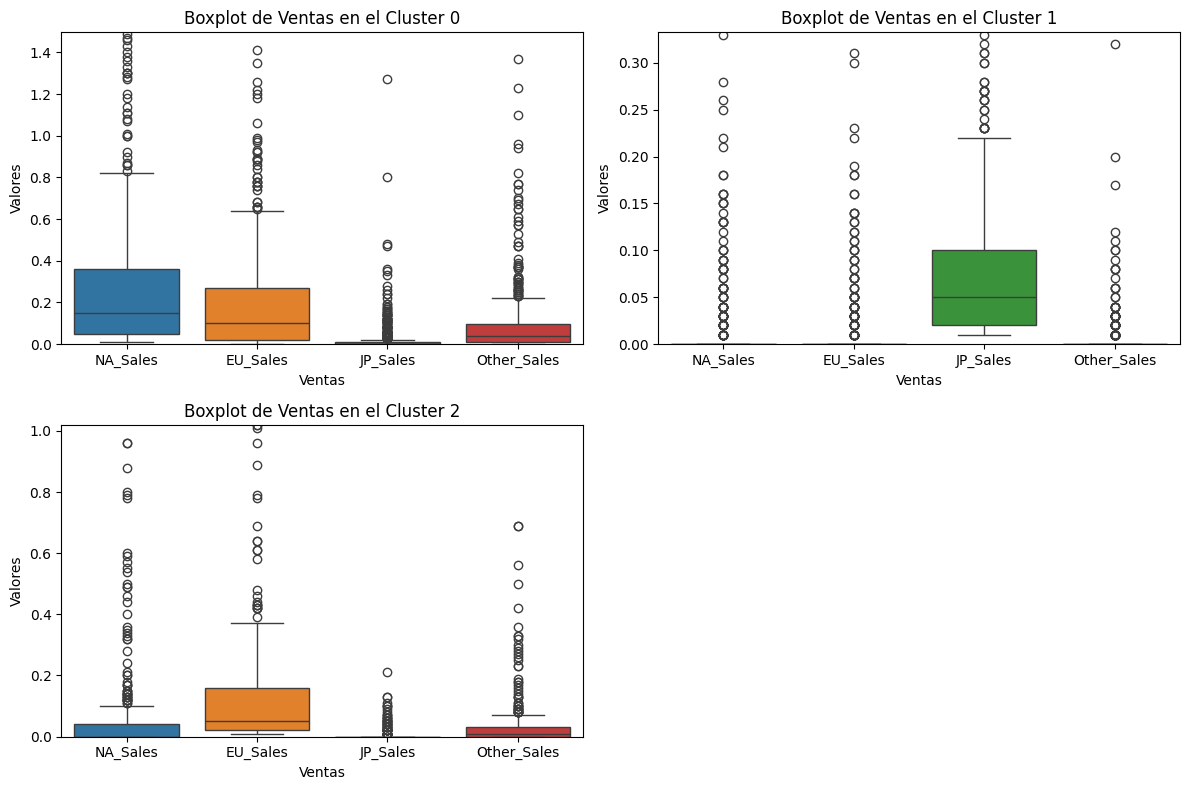

In [ ]:
# Definir las columnas de ventas
ventas = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Establecer el tamaño de la figura
plt.figure(figsize=(12, 8))

# Crear un gráfico de cajas para cada cluster
clusters = data_clustered['Cluster'].unique()

# Crear un gráfico de cajas por cluster
for i, cluster in enumerate(clusters):
    # Filtrar los datos para el cluster actual
    data_cluster = data_clustered[data_clustered['Cluster'] == cluster]

    # Calcular los percentiles 5% y 95% para cada columna de ventas
    limites_y = data_cluster[ventas].quantile([0.05, 0.95])

    # Crear subgráficos para cada cluster (un solo gráfico por cluster)
    plt.subplot(2, 2, i + 1)  # Usamos una cuadrícula 2x2 para los gráficos
    sns.boxplot(data=data_cluster[ventas])  # Graficamos las 4 columnas de ventas en el mismo gráfico

    # Establecer los límites del eje y para que muestre el 90% central
    plt.ylim(limites_y.loc[0.05].min(), limites_y.loc[0.95].max())  # Usamos el mínimo del 5% y máximo del 95% para todos los gráficos

    # Títulos y etiquetas
    plt.title(f'Boxplot de Ventas en el Cluster {cluster}')
    plt.xlabel('Ventas')
    plt.ylabel('Valores')

# Ajustar los espacios entre los subgráficos
plt.tight_layout()
plt.show()


 Ocultar los puntos atípicos para no interferir con la visualización de las cajas.

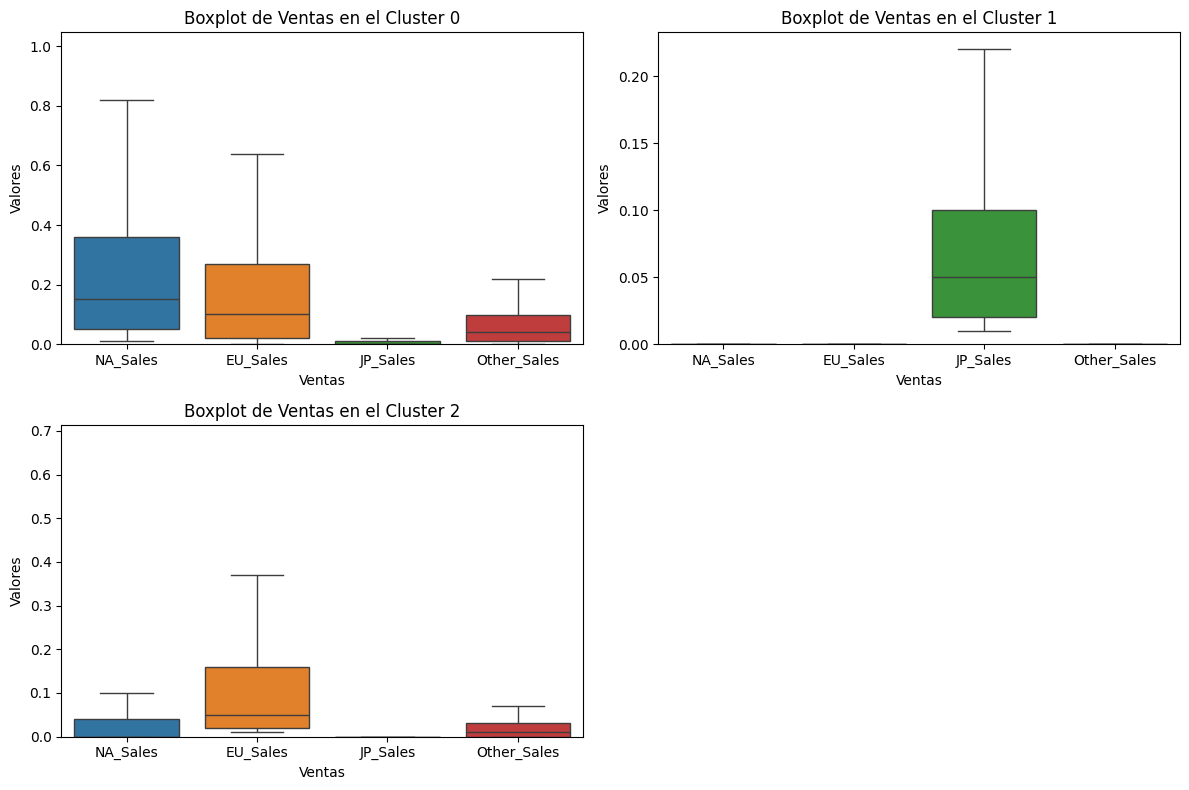

In [ ]:
# Definir las columnas de ventas
ventas = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Establecer el tamaño de la figura
plt.figure(figsize=(12, 8))

# Crear un gráfico de cajas para cada cluster
clusters = data_clustered['Cluster'].unique()

# Crear un gráfico de cajas por cluster
for i, cluster in enumerate(clusters):
    # Filtrar los datos para el cluster actual
    data_cluster = data_clustered[data_clustered['Cluster'] == cluster]

    # Calcular los percentiles 5% y 95% para cada columna de ventas
    limites_y = data_cluster[ventas].quantile([0.05, 0.95])

    # Obtener los valores de los bigotes (valores máximos no atípicos)
    # Se calcula el límite superior de cada columna de ventas para usarlo como límite superior en el gráfico
    limites_superiores = data_cluster[ventas].apply(lambda x: x.max() if x.max() <= limites_y.loc[0.95].max() else limites_y.loc[0.95].max())

    # Crear subgráficos para cada cluster (un solo gráfico por cluster)
    plt.subplot(2, 2, i + 1)  # Usamos una cuadrícula 2x2 para los gráficos
    sns.boxplot(data=data_cluster[ventas], showfliers=False)  # Graficamos las 4 columnas de ventas sin puntos atípicos

    # Establecer los límites del eje y para ajustarlo más cerca de la caja
    y_max = limites_superiores.max() * 0.70  # Un pequeño margen por encima del valor máximo de la caja
    y_min = limites_y.loc[0.05].min()  # El mínimo de la caja lo obtenemos del 5%

    # Ajustar el límite superior e inferior para evitar demasiado espacio por encima
    plt.ylim(y_min, y_max)

    # Títulos y etiquetas
    plt.title(f'Boxplot de Ventas en el Cluster {cluster}')
    plt.xlabel('Ventas')
    plt.ylabel('Valores')

# Ajustar los espacios entre los subgráficos
plt.tight_layout()
plt.show()


<Figure size 1200x800 with 0 Axes>

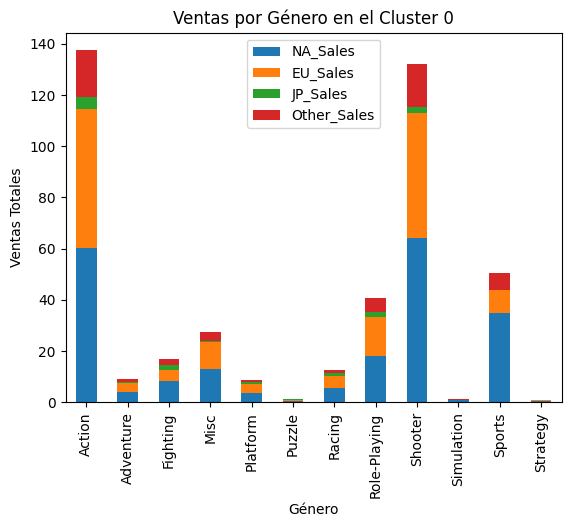

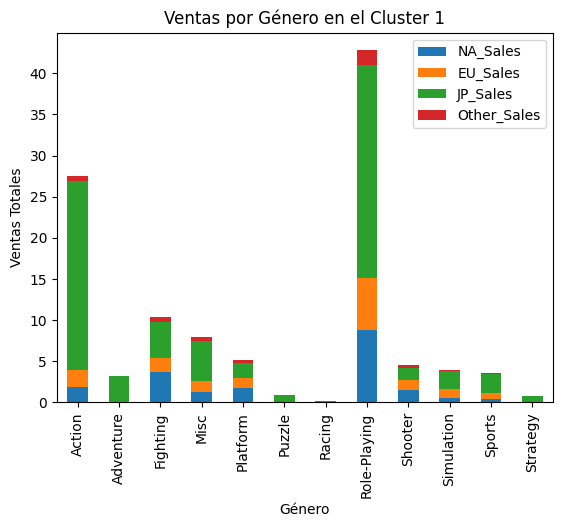

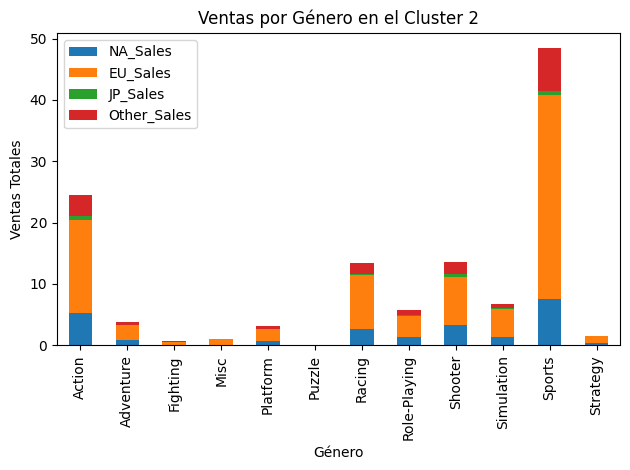

In [ ]:
# Agrupar los datos por 'Cluster' y 'Genre' y sumar las ventas
ventas_por_cluster_genero = data_clustered.groupby(['Cluster', 'Genre'])[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum().reset_index()

# Para crear gráficos separados por 'Cluster', podemos filtrar los datos por cada cluster
clusters = ventas_por_cluster_genero['Cluster'].unique()

# Establecer el tamaño de la figura
plt.figure(figsize=(12, 8))

# Crear un gráfico para cada cluster
for i, cluster in enumerate(clusters):
    # Filtrar los datos para el cluster actual
    data_cluster = ventas_por_cluster_genero[ventas_por_cluster_genero['Cluster'] == cluster]

    # Crear un gráfico de barras apiladas para cada cluster
    #plt.subplot(2, 2, i + 1)  # Usamos una cuadrícula 2x2 para los gráficos
    data_cluster.set_index('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].plot(kind='bar', stacked=True)

    # Título y etiquetas
    plt.title(f'Ventas por Género en el Cluster {cluster}')
    plt.xlabel('Género')
    plt.ylabel('Ventas Totales')

# Ajustar los espacios entre los subgráficos
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

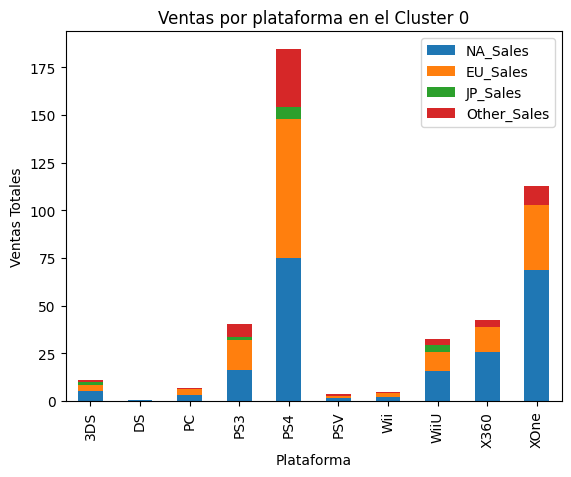

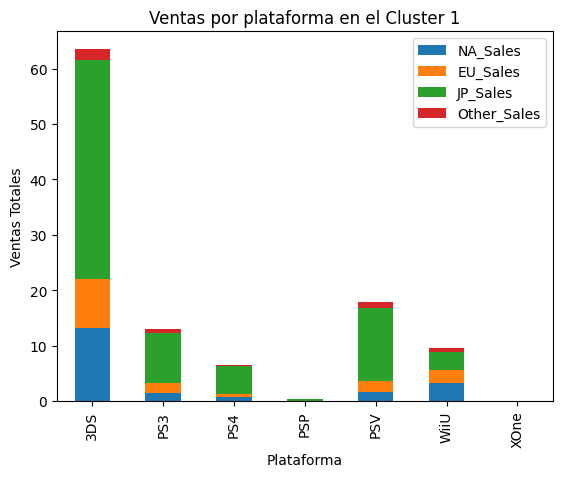

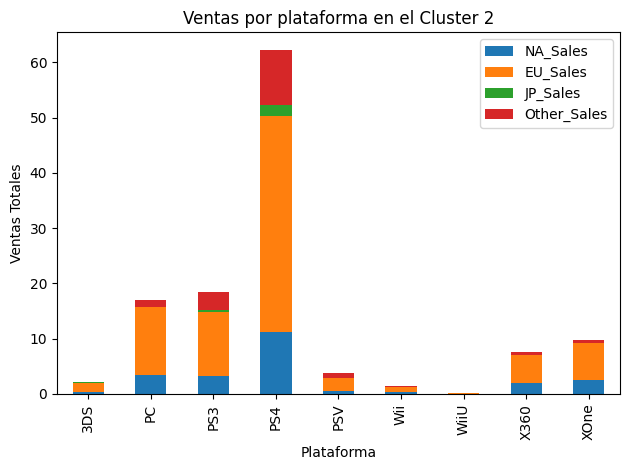

In [ ]:
# Agrupar los datos por 'Cluster' y 'Platform' y sumar las ventas
ventas_por_cluster_plataforma = data_clustered.groupby(['Cluster', 'Platform'])[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum().reset_index()

# Para crear gráficos separados por 'Cluster', podemos filtrar los datos por cada cluster
clusters = ventas_por_cluster_plataforma['Cluster'].unique()

# Establecer el tamaño de la figura
plt.figure(figsize=(12, 8))

# Crear un gráfico para cada cluster
for i, cluster in enumerate(clusters):
    # Filtrar los datos para el cluster actual
    data_cluster = ventas_por_cluster_plataforma[ventas_por_cluster_plataforma['Cluster'] == cluster]

    # Crear un gráfico de barras apiladas para cada cluster
    #plt.subplot(2, 2, i + 1)  # Usamos una cuadrícula 2x2 para los gráficos
    data_cluster.set_index('Platform')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].plot(kind='bar', stacked=True)

    # Título y etiquetas
    plt.title(f'Ventas por plataforma en el Cluster {cluster}')
    plt.xlabel('Plataforma')
    plt.ylabel('Ventas Totales')

# Ajustar los espacios entre los subgráficos
plt.tight_layout()
plt.show()